### first part

In [1]:
import sys
sys.path.insert(0, "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/src")

import os
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

from vit_prisma.utils.constants import BASE_DIR, DATA_DIR, MODEL_DIR, DEVICE, MODEL_CHECKPOINTS_DIR
from vit_prisma.utils.tutorial_utils import calculate_clean_accuracy, load_clip_models, plot_image, get_feature_activations
from vit_prisma.utils.data_utils.loader import load_dataset
from vit_prisma.utils.tutorial_utils import plot_act_distribution
from vit_prisma.utils.tutorial_utils import plot_top_imgs_for_features

/home/nfm/prisma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nfm/prisma/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [2]:
DEVICE = 'cuda' # change to cpu if cpu only paradigm
BATCH_SIZE = 16

In [3]:
# Load an SAE
from huggingface_hub import hf_hub_download, list_repo_files
from vit_prisma.sae import SparseAutoencoder
import glob

def load_sae(repo_id, file_name, config_name):
    # Step 1: Download SAE from Hugginface
    sae_path = hf_hub_download(repo_id, file_name) # Download weights
    hf_hub_download(repo_id, config_name) # Download config

    # sae_path = repo_id
    # Step 2: Load the pretrained SAE weights from the downloaded path
    print(f"Loading SAE from {sae_path}...")
    sae = SparseAutoencoder.load_from_pretrained(sae_path) # This now automatically gets config.json and converts into the VisionSAERunnerConfig object
    return sae

def my_load_sae(pth):
    config_path = os.path.join(pth, "config.json")
    # weights_path = os.path.join(pth, "n_images_13000704.pt")
    weights = glob.glob(os.path.join(pth, "*.pt"))
    weights.sort(key=lambda x: int(''.join(filter(str.isdigit, os.path.basename(x)))))
    weights = [w for w in weights if not "log_" in os.path.basename(w)]
    weights_path = weights[-1]

    print(f"----------------Loading SAE from {weights_path} ----------------")

    sae = SparseAutoencoder.load_from_pretrained(weights_path=weights_path, config_path=config_path) # This now automatically gets config.json and converts into the VisionSAERunnerConfig object
    sae.eval()
    sae.to(DEVICE)
    
    return sae

repo_id = "Prisma-Multimodal/sparse-autoencoder-clip-b-32-sae-vanilla-x64-layer-10-hook_mlp_out-l1-1e-05" # Change this to your chosen SAE. See /docs for a list of SAEs.
repo_id2 = "/home/nfm/ViT-Prisma/demos/sae_ckpts/ee158df6-tinyclip_sae_16_hyperparam_sweep_lr"
repo_id3 = "/home/nfm/ViT-Prisma/demos/sae_ckpts/892ec2b9-tinyclip_sae_16_hyperparam_sweep_lr"
repo_id4 = "/home/nfm/ViT-Prisma/demos/sae_ckpts/f103614d-tinyclip_sae_16_hyperparam_sweep_lr"
repo_id5 = "/home/nfm/ViT-Prisma/demos/sae_ckpts/59fcae83-sae_training_clip_b16"
repo_id6 = "/home/nfm/ViT-Prisma/demos/sae_ckpts/82d22c1d-sae_training_clip_b16_cls_only"
repo_id7 = "/home/nfm/ViT-Prisma/demos/sae_ckpts/2e0029a5-claude_clip2_topk"
repo_id7 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/sae_ckpts/29e0111c-claude_topk_all"
file_name = "weights.pt"
config_name = "config.json"
sae = my_load_sae(repo_id7)
# sae = load_sae(repo_id, file_name, config_name)

----------------Loading SAE from /home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/sae_ckpts/29e0111c-claude_topk_all/n_images_6500008.pt ----------------


2026-06-21 23:34:09 WARNING:root: Warning: We are initializing b_dec to zeros. This is probably not what you want.
2026-06-21 23:34:09 INFO:root: n_tokens_per_buffer (millions): 1.613824
2026-06-21 23:34:09 INFO:root: Lower bound: n_contexts_per_buffer (millions): 0.008192
2026-06-21 23:34:09 INFO:root: Total training steps: 625244
2026-06-21 23:34:09 INFO:root: Total training images: 6500000
2026-06-21 23:34:09 INFO:root: Total wandb updates: 62524
2026-06-21 23:34:09 INFO:root: Expansion factor: 16
2026-06-21 23:34:09 INFO:root: n_tokens_per_feature_sampling_window (millions): 201.728
2026-06-21 23:34:09 INFO:root: n_tokens_per_dead_feature_window (millions): 2017.28
2026-06-21 23:34:09 INFO:root: We will reset the sparsity calculation 1250 times.
2026-06-21 23:34:09 INFO:root: Number tokens in sparsity calculation window: 1.02e+06
2026-06-21 23:34:09 INFO:root: Gradient clipping with max_norm=1.0
2026-06-21 23:34:09 INFO:root: Using SAE initialization method: independent
2026-06-21 

In [4]:
from pprint import pprint
sae.cfg
pprint(sae.cfg)

VisionModelSAERunnerConfig(model_class_name='HookedViT',
                           model_name='open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K',
                           vit_model_cfg=None,
                           model_path=None,
                           hook_point_layer=11,
                           layer_subtype='hook_resid_post',
                           hook_point_head_index=None,
                           context_size=197,
                           use_cached_activations=True,
                           use_patches_only=False,
                           cached_activations_path='/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/blocks11_resid_post_all',
                           image_size=224,
                           architecture='standard',
                           b_dec_init_method='zeros',
                           expansion_factor=16,
                           from_pretrained_path=None,
                           is_transcoder=False,
         

In [5]:
# Load model
from vit_prisma.models.model_loader import load_hooked_model

model_name = sae.cfg.model_name
model = load_hooked_model(model_name)
model.to(DEVICE); # Move to device

2026-06-21 23:34:09 INFO:root: Model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' is supported and passes tests.
2026-06-21 23:34:09 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-06-21 23:34:09 DEBUG:urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443


*****Loading model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' of type 'VISION'


2026-06-21 23:34:10 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_config.json HTTP/1.1" 307 0
2026-06-21 23:34:10 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/laion/CLIP-ViT-B-16-laion2B-s34B-b88K/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_config.json HTTP/1.1" 200 0
2026-06-21 23:34:10 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-06-21 23:34:10 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_pytorch_model.bin HTTP/1.1" 302 0
2026-06-21 23:34:11 INFO:root: visual projection shape: torch.Size([768, 512])
2026-06-21 23:34:12 INFO:root: Loaded pretrained model open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K into HookedTransformer


In [6]:
# Put paths here
from vit_prisma.transforms import get_clip_val_transforms
from torchvision import datasets, transforms
import torchvision

def load_imagenet(imagenet_validation_path, model_type="clip"):
    torch.set_grad_enabled(False)


    # Load dataset with CLIP transform
    if model_type == "clip":
        data_transforms = get_clip_val_transforms()
    else:
        data_transforms = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    val_data = torchvision.datasets.ImageFolder(imagenet_validation_path, transform=data_transforms)

    # We'll also load a version of the dataset without the CLIP transform so that we can visualize it beautifully
    viz_transforms = torchvision.transforms.Compose(
                    [
                        torchvision.transforms.Resize((224, 224)),
                        torchvision.transforms.ToTensor(),
                    ]
                )
    viz_data = torchvision.datasets.ImageFolder(imagenet_validation_path, transform=viz_transforms)

    # We only want a subset of validation
            
    subset_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    # We only want a subset 
    
    return subset_dataloader, val_data, viz_data

# Put your imagenet path here. You can download ImageNet from kaggle.
imagenet_validation_path = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val'
full_dataloader, full_dataset, full_viz_data = load_imagenet(imagenet_validation_path)

print(f"Number of samples in the subset: {len(full_dataloader.dataset)}")
print(f"Number of samples in the full dataset: {len(full_dataset)}")

Number of samples in the subset: 50000
Number of samples in the full dataset: 50000


In [7]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from vit_prisma.transforms import get_clip_val_transforms
import numpy as np

def load_imagenet(imagenet_validation_path, images_per_class=5, model_type="clip"):
    torch.set_grad_enabled(False)
    
    # 1. Load the full dataset first (this just indexes the files, doesn't load images into RAM)
    if model_type == "clip":
        data_transforms = get_clip_val_transforms()
    else:
        data_transforms = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    full_val_data = datasets.ImageFolder(imagenet_validation_path, transform=data_transforms)
    
    viz_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    full_viz_data = datasets.ImageFolder(imagenet_validation_path, transform=viz_transforms)

    # 2. Logic to pick 5 indices per class
    targets = np.array(full_val_data.targets)
    subset_indices = []
    
    for class_idx in range(len(full_val_data.classes)):
        # Find all indices belonging to this class
        class_indices = np.where(targets == class_idx)[0]
        # Take the first 'n' images
        subset_indices.extend(class_indices[:images_per_class])

    # 3. Create the Subsets
    val_subset = Subset(full_val_data, subset_indices)
    viz_subset = Subset(full_viz_data, subset_indices)

    # 4. Create Dataloader from the subset
    subset_dataloader = DataLoader(
        val_subset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=4
    )

    return subset_dataloader, val_subset, viz_subset

# Usage
imagenet_validation_path = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val'
subset_dataloader, subset_dataset, viz_data = load_imagenet(imagenet_validation_path, images_per_class=5, model_type="clip")

### DFA

In [8]:
import json
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}

idx_to_wnid = {int(idx): wnid for idx, (wnid, name) in imagenet_class_index.items()}
name_to_idx = {name: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}

# indices_dict = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

indices_dict = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/text_to_image_indices.json", "r"))

In [11]:
# pth = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/blocks11_resid_post_cls/0.pt"
# activation = torch.load(pth)
# print(f"Activation shape: {activation.shape}")

In [9]:
import os
import json
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import open_clip
from tqdm import tqdm

# --- Configuration ---
IMAGENET_VAL_DIR = "/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/"
TEXT_FILE_PATH = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"

# OpenCLIP specific model strings
MODEL_NAME = "ViT-B-16"
PRETRAINED = "laion2b_s34b_b88k"

BATCH_SIZE = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_EMBEDDINGS_PATH = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/imagenet_100k_embeddings.pt"
OUTPUT_DICT_PATH = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/text_to_image_indices.json"

# --- 1. Load OpenCLIP Model, Preprocessor, and Tokenizer ---
print(f"Loading OpenCLIP model: {MODEL_NAME} ({PRETRAINED})...")
# 'preprocess' is a ready-to-use torchvision transform tailored for this specific model
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED)
model = model.to(DEVICE)
model.eval()

tokenizer = open_clip.get_tokenizer(MODEL_NAME)

# --- 2. Load Datasets ---
print("Loading ImageNet subset...")
# We can pass the OpenCLIP preprocess function directly to ImageFolder
dataset = ImageFolder(root=IMAGENET_VAL_DIR, transform=preprocess)

# STRICTLY NO SHUFFLE to keep indices deterministic
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=6, pin_memory=True)

print("Loading text descriptions...")
with open(TEXT_FILE_PATH, "r", encoding="utf-8") as f:
    texts = [line.strip() for line in f if line.strip()]

# # --- 3. Extract Image Embeddings ---
# print(f"Extracting embeddings for {len(dataset)} images...")
# all_image_embeds = []

# with torch.no_grad():
#     for images, _ in tqdm(dataloader):
#         images = images.to(DEVICE)
        
#         # OpenCLIP uses encode_image instead of get_image_features
#         image_features = model.encode_image(images)
        
#         # Normalize for cosine similarity
#         image_features /= image_features.norm(dim=-1, keepdim=True)
#         all_image_embeds.append(image_features.cpu())

# # Stack into a single [100000, dim] tensor
# all_image_embeds = torch.cat(all_image_embeds, dim=0)
# print(f"Saving image embeddings to {OUTPUT_EMBEDDINGS_PATH}. Shape: {all_image_embeds.shape}")
# torch.save(all_image_embeds, OUTPUT_EMBEDDINGS_PATH)
# print("Loading text descriptions...")

with open(TEXT_FILE_PATH, "r", encoding="utf-8") as f:
    texts = [line.strip() for line in f if line.strip()]
all_image_embeds = torch.load("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/imagenet_100k_embeddings.pt", map_location=DEVICE)
# --- 4. Extract Text Embeddings & Run Retrieval ---
print(f"Processing {len(texts)} text queries...")
all_image_embeds = all_image_embeds.to(DEVICE)
retrieval_dict = {}

TEXT_BATCH_SIZE = 64
counter = 0
for i in tqdm(range(0, len(texts), TEXT_BATCH_SIZE)):
    batch_texts = texts[i:i+TEXT_BATCH_SIZE]
    
    with torch.no_grad():
        # OpenCLIP tokenizer returns a tensor ready for the model
        text_tokens = tokenizer(batch_texts).to(DEVICE)
        text_features = model.encode_text(text_tokens)
        
        # Normalize
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        # Compute cosine similarity matrix: [text_batch, 100000]
        similarity = torch.matmul(text_features, all_image_embeds.T)
        
        # Get top 50 images for each text in the batch
        top_k_values, top_k_indices = torch.topk(similarity, k=50, dim=-1)
        
        # Store results back into dictionary
        for j, text in enumerate(batch_texts):
            retrieval_dict[counter] = top_k_indices[j].cpu().tolist()
            counter += 1

# --- 5. Save Retrieval Results ---
print(f"Saving retrieval index to {OUTPUT_DICT_PATH}...")
with open(OUTPUT_DICT_PATH, "w", encoding="utf-8") as f:
    json.dump(retrieval_dict, f, indent=4, ensure_ascii=False)

print("Pipeline complete successfully!")

2026-06-17 12:20:23 INFO:root: Parsing model identifier. Schema: None, Identifier: ViT-B-16
2026-06-17 12:20:23 INFO:root: Loaded built-in ViT-B-16 model config.
2026-06-17 12:20:23 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_model.safetensors HTTP/1.1" 302 0
2026-06-17 12:20:23 INFO:root: Instantiating model architecture: CLIP


Loading OpenCLIP model: ViT-B-16 (laion2b_s34b_b88k)...


2026-06-17 12:20:25 INFO:root: Loading full pretrained weights from: /home/nfm/.cache/huggingface/hub/models--laion--CLIP-ViT-B-16-laion2B-s34B-b88K/snapshots/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_model.safetensors
2026-06-17 12:20:25 INFO:root: Final image preprocessing configuration set: {'size': (224, 224), 'mode': 'RGB', 'mean': (0.48145466, 0.4578275, 0.40821073), 'std': (0.26862954, 0.26130258, 0.27577711), 'interpolation': 'bicubic', 'resize_mode': 'shortest', 'fill_color': 0}
2026-06-17 12:20:25 INFO:root: Model ViT-B-16 creation process complete.
2026-06-17 12:20:25 INFO:root: Parsing tokenizer identifier. Schema: None, Identifier: ViT-B-16
2026-06-17 12:20:25 INFO:root: Attempting to load config from built-in: ViT-B-16
2026-06-17 12:20:25 INFO:root: Using default SimpleTokenizer.


Loading ImageNet subset...
Loading text descriptions...
Processing 3498 text queries...


100%|██████████| 55/55 [00:02<00:00, 22.51it/s]


Saving retrieval index to /home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/text_to_image_indices.json...
Pipeline complete successfully!


top images for text query: Image taken in Grand Canyon


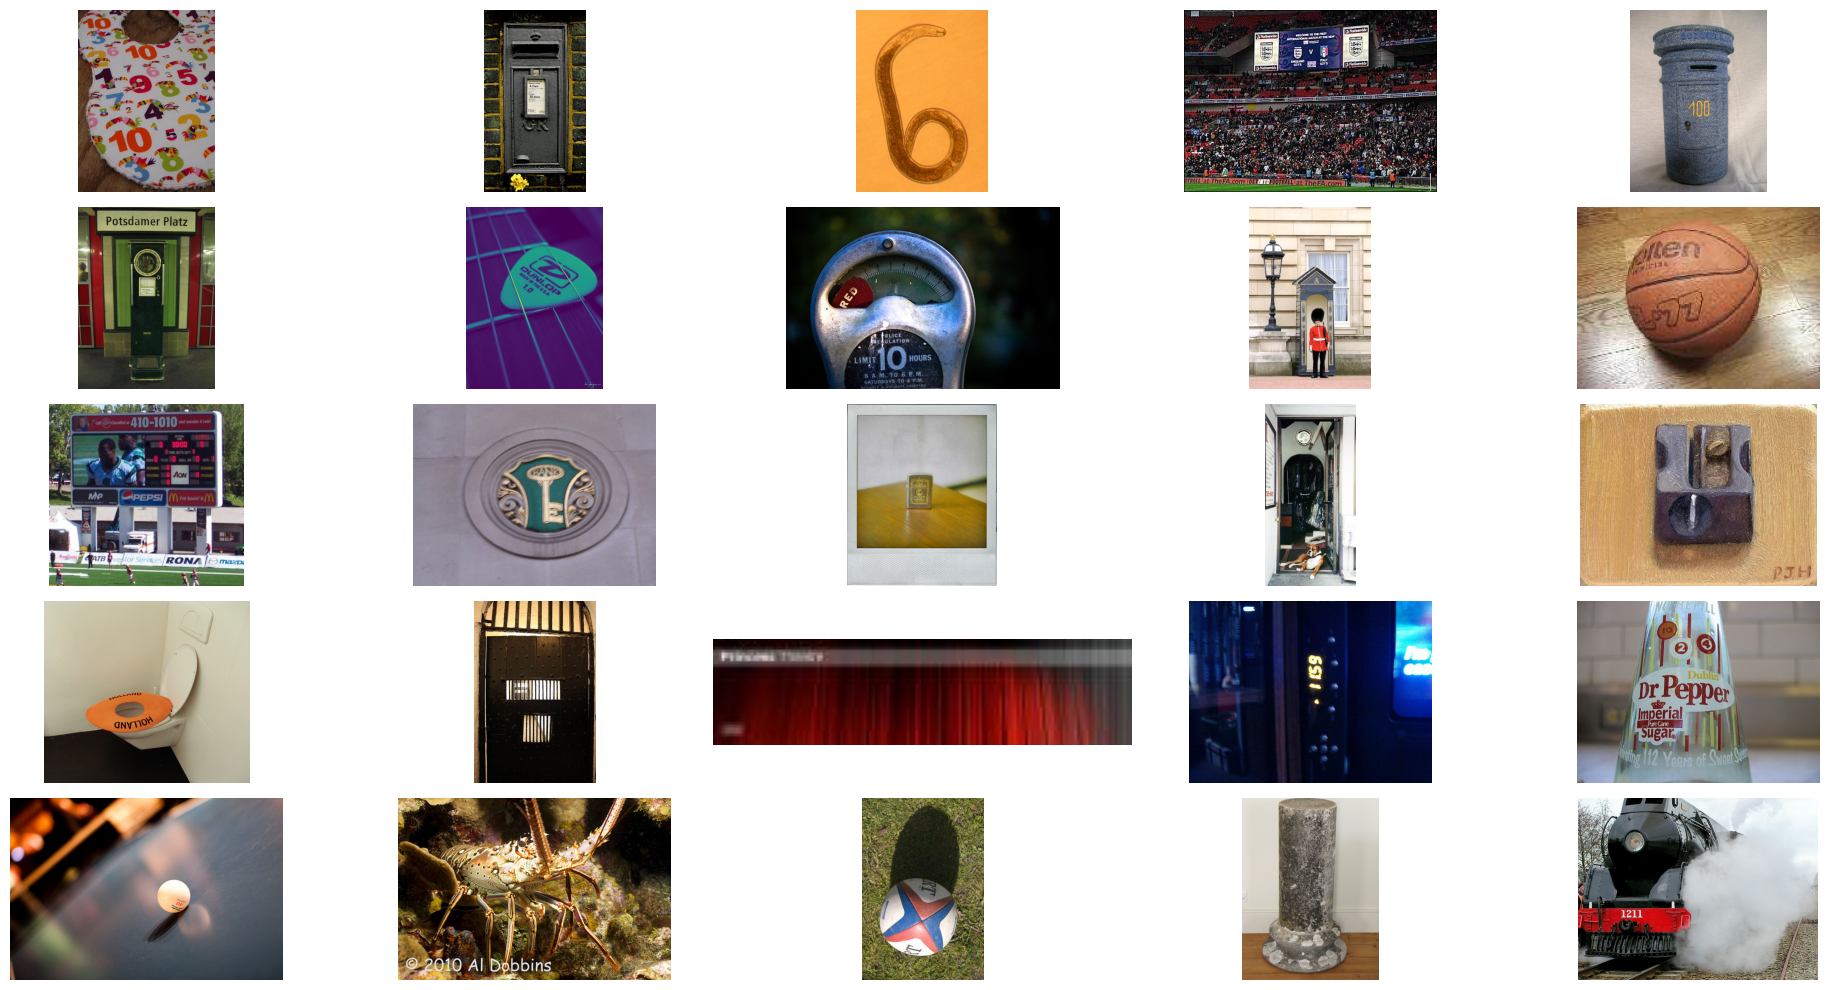

In [26]:
import random
import matplotlib.pyplot as plt

idx = random.randint(0, len(texts) - 1)
print("top images for text query:", texts[idx])

target_txt = "A photo with the letter D"
target_txt = "An image of the number 10"
idx = texts.index(target_txt)

img_inds = retrieval_dict[idx]

fig, axes = plt.subplots(5, 5, figsize=(20, 10))
for i, ax in enumerate(axes.flatten()):
    if i < len(img_inds):
        img_path, _ = dataset.samples[img_inds[i]]
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')
plt.tight_layout()

In [9]:
TEXT_FILE_PATH = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"

print("Loading text descriptions...")
with open(TEXT_FILE_PATH, "r", encoding="utf-8") as f:
    texts = [line.strip() for line in f if line.strip()]

Loading text descriptions...


### wrong part

In [ ]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import open_clip

# --- 1. CONFIGURATION ---
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/'
# OUTPUT_PATH = '/home/nfm/ViT-Prisma/demos/vit_feature_scores_newdataset.pt'
OUTPUT_PATH = '/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/clip_sae_feature_scores_topk_top20.pt'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
BATCH_SIZE = 50 # Exactly 1 class per batch
DEVICE = 'cuda'

# --- 2. LOAD CLASS NAMES ---
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

# Create a mapping from simple integer index (0-999) to clean class names
idx_to_name = {}
for str_idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    idx_to_name[int(str_idx)] = safe_class_name

# mytransform = get_clip_val_transforms()
# mytransform = transforms.Compose([
#         transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
#         transforms.CenterCrop(224),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
#         ])

# --- 3. DATASET & DATALOADER ---
# Assuming 'transform' is defined (use the appropriate timm/CLIP transform)
# import preprocess from openclip
_, _, preprocess = open_clip.create_model_and_transforms("ViT-B-16", pretrained="laion2b_s34b_b88k")
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=preprocess) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# --- 4. PREPARE THE SCORE MATRIX ---
# Assuming your SAE dimension is 12288 (768 * 16)
num_features = sae.cfg.d_in * sae.cfg.expansion_factor 
# num_classes = 1000
indices_dict = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/text_to_image_indices.json", "r"))
num_classes = len(indices_dict)

# Shape: [12288 features, 1000 classes]
feature_class_scores = torch.zeros((num_features, num_classes), dtype=torch.float32, device=DEVICE)

model.eval()
sae.eval()

print(f"Extracting SAE activations for {num_classes} classes...")

batch_size = 20*20

# --- 5. MAIN EXTRACTION LOOP ---
with torch.no_grad():
    # for batch_imgs, batch_labels in tqdm(dataloader, total=len(dataloader)):
    batch_indices = []
    class_indices = []
    for i in tqdm(range(num_classes)):
        batch_indices = batch_indices + list(indices_dict[str(i)][:20])
        class_indices.append(i)
        if len(batch_indices) == batch_size:
            batch_imgs = torch.stack([dataset[idx][0] for idx in batch_indices]) #
            batch_imgs = batch_imgs.to(DEVICE)
            
            # Since batch_size=50, all labels in this batch are the same class
            # class_idx = batch_labels[0].item()
            # class_idx = i
            # class_indices.append(class_idx)

            # 1. Run forward pass through ViT to get the hook activations
            _, cache = model.run_with_cache(batch_imgs, names_filter=sae.cfg.hook_point)
            hook_point_activation = cache[sae.cfg.hook_point] # Shape: [50, 50, 768] (or 197 for patch16)
            # break

            # 2. Extract ONLY the CLS token
            cls_activation = hook_point_activation[:, 0, :] # Shape: [50, 768]

            # 3. Calculate SAE features for the CLS tokens
            _, feature_acts, *_ = sae(cls_activation) # Shape: [50, 12288]

            for class_idx in class_indices:
                # avg_feature_acts = feature_acts.mean(dim=0) # Shape: [12288]
                avg_feature_acts = feature_acts[class_idx:class_idx+20].mean(dim=0) # Shape: [12288]
                feature_class_scores[:, class_idx] = avg_feature_acts
            # break
            batch_indices = []
            class_indices = []
        

# # --- 6. SAVE TO DISK ---
# torch.save(feature_class_scores.cpu(), OUTPUT_PATH)
# print(f"Complete! Saved [12288, {num_classes}] tensor to {OUTPUT_PATH}")

2026-06-20 10:08:56 INFO:root: Parsing model identifier. Schema: None, Identifier: ViT-B-16
2026-06-20 10:08:56 INFO:root: Loaded built-in ViT-B-16 model config.
2026-06-20 10:08:56 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_model.safetensors HTTP/1.1" 302 0
2026-06-20 10:08:56 INFO:root: Instantiating model architecture: CLIP
2026-06-20 10:08:57 INFO:root: Loading full pretrained weights from: /home/nfm/.cache/huggingface/hub/models--laion--CLIP-ViT-B-16-laion2B-s34B-b88K/snapshots/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_model.safetensors
2026-06-20 10:08:58 INFO:root: Final image preprocessing configuration set: {'size': (224, 224), 'mode': 'RGB', 'mean': (0.48145466, 0.4578275, 0.40821073), 'std': (0.26862954, 0.26130258, 0.27577711), 'interpolation': 'bicubic', 'resize_mode': 'shortest', 'fill_color': 0}
2026-06-20 10:08:58 INFO:root: Model ViT-B-16 creation process complete.


Extracting SAE activations for 3498 classes...


  0%|          | 0/3498 [00:00<?, ?it/s]


In [27]:
OUTPUT_PATH = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/clip_sae_feature_scores_topk_top20.pt"
feature_class_scores = torch.load(OUTPUT_PATH, map_location=DEVICE)
feature_class_scores.shape

torch.Size([12288, 3498])

2026-06-17 14:05:15 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-17 14:05:15 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-17 14:05:15 DEBUG:matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-17 14:05:15 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/home/nfm/prisma/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-17 14:05:15 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/home/nfm/prisma/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-06-17 14:05:15 DEBUG:mat

Text(0, 0.5, 'Frequency')

2026-06-17 14:05:16 DEBUG:matplotlib.ticker: vmin 0.4623089406309083 vmax 10874814.562614754
2026-06-17 14:05:16 DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08, 1.e+09])
2026-06-17 14:05:16 DEBUG:matplotlib.ticker: vmin 0.4623089406309083 vmax 10874814.562614754
2026-06-17 14:05:16 DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05,
       2.e+06, 3.e+06, 4.e+

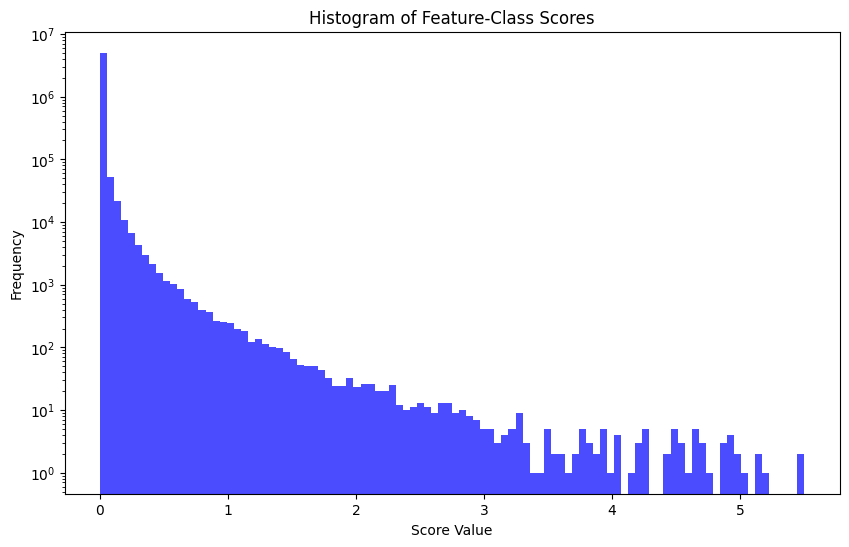

In [11]:
# histogram of flattened feature_class_scores, log scale
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(feature_class_scores.cpu().numpy().flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histogram of Feature-Class Scores')
plt.xlabel('Score Value')
plt.ylabel('Frequency')
plt.yscale('log')
plt.ylabel('Frequency')

In [16]:
print(feature_class_scores.shape)

# number of nan values in feature_class_scores
num_nans = torch.isnan(feature_class_scores).sum().item()
print(f"Number of NaN values in feature_class_scores: {num_nans}")

#number of inf, zero, negative and positive values in feature_class_scores
num_infs = torch.isinf(feature_class_scores).sum().item()
num_zeros = (feature_class_scores == 0).sum().item()
num_negatives = (feature_class_scores < 0).sum().item()
num_positives = (feature_class_scores > 0).sum().item()

print(f"Number of Inf values: {num_infs}")
print(f"Number of Zero values: {num_zeros}")
print(f"Number of Negative values: {num_negatives}")
print(f"Number of Positive values: {num_positives}")

torch.Size([12288, 3498])
Number of NaN values in feature_class_scores: 0
Number of Inf values: 0
Number of Zero values: 42437739
Number of Negative values: 0
Number of Positive values: 545685


In [44]:
printed = 0
for feat_idx in range(511, feature_class_scores.shape[0]):
    if printed == 20:
        break
    scores = feature_class_scores[feat_idx]
    valid_scores = scores.clone()
    valid_scores[torch.isnan(valid_scores)] = 0.0

    if valid_scores.max() == 0:
        continue

    top_vals, top_idxs = valid_scores.topk(5)
    print(f"\nFeature {feat_idx}:")
    for val, idx in zip(top_vals, top_idxs):
        if val > 0:
            print(f"  {texts[idx]:40s}  {val:.4f}")
    printed += 1


Feature 518:
  An image of a Attorney                    0.1948
  An image of a Athlete                     0.1948
  A boot                                    0.1639
  A bookmark                                0.1639
  A book                                    0.1639

Feature 525:
  A deck                                    0.1978
  A decagon                                 0.1978
  A diamond                                 0.1978
  A dodecagon                               0.1978
  A digital glitch design                   0.1978

Feature 566:
  An image of hands                         2.4248
  an image of glasgow                       1.2124
  An image of friends hanging out           0.8083
  An image of fish                          0.6062
  A helmet                                  0.5277

Feature 628:
  An image of friends hanging out           0.6591
  An image of fish                          0.4943
  An equilateral hexagon                    0.4725
  An ellipse              

In [53]:
for i in range(feature_class_scores.shape[0]):
    print(feature_class_scores[i].max())
    break

tensor(nan, device='cuda:0')


In [2]:
import torch

pth = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/blocks11_resid_post_all/19.pt"

tensor = torch.load(pth, map_location='cpu')
tensor.shape

torch.Size([500000, 1, 768])

### fixed part

In [8]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import open_clip
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
BATCH_SIZE = 50
DEVICE = 'cuda'
_, _, preprocess = open_clip.create_model_and_transforms("ViT-B-16", pretrained="laion2b_s34b_b88k")
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=preprocess) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

2026-06-21 23:34:13 INFO:root: Parsing model identifier. Schema: None, Identifier: ViT-B-16
2026-06-21 23:34:13 INFO:root: Loaded built-in ViT-B-16 model config.
2026-06-21 23:34:13 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_model.safetensors HTTP/1.1" 302 0
2026-06-21 23:34:13 INFO:root: Instantiating model architecture: CLIP
2026-06-21 23:34:15 INFO:root: Loading full pretrained weights from: /home/nfm/.cache/huggingface/hub/models--laion--CLIP-ViT-B-16-laion2B-s34B-b88K/snapshots/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_model.safetensors
2026-06-21 23:34:15 INFO:root: Final image preprocessing configuration set: {'size': (224, 224), 'mode': 'RGB', 'mean': (0.48145466, 0.4578275, 0.40821073), 'std': (0.26862954, 0.26130258, 0.27577711), 'interpolation': 'bicubic', 'resize_mode': 'shortest', 'fill_color': 0}
2026-06-21 23:34:15 INFO:root: Model ViT-B-16 creation process complete.


### save (768x16) by 3500

In [62]:
import json
from tqdm.auto import tqdm

TOKEN_POOL        = 'mean'   # collapse 197 tokens/image -> 1 vector: 'mean' (avg strength) or 'max' (peak)
IMAGES_PER_CLASS  = 10
CLASSES_PER_BATCH = 5        # keep small: all-patches has 197x more tokens/image than CLS

num_features = sae.cfg.d_sae
indices_dict = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/text_to_image_indices.json"))
num_classes  = len(indices_dict)
feature_class_scores = torch.zeros((num_features, num_classes), dtype=torch.float32, device=DEVICE)

model.eval(); sae.eval()

@torch.no_grad()
def image_feature_vectors(imgs, pool=TOKEN_POOL):
    """imgs [B,3,H,W] -> [B, d_sae]. CLS-only sae uses the CLS token; all-patches pools over all tokens."""
    _, cache = model.run_with_cache(
        imgs, names_filter=sae.cfg.hook_point,
        stop_at_layer=sae.cfg.hook_point_layer + 1,        # don't run layers we don't need
    )
    acts   = cache[sae.cfg.hook_point]                     # [B, T, 768]  (T = 1 if CLS hook returns 1, else 197)
    tokens = acts[:, 0:1, :] if sae.cfg.cls_token_only else acts
    B, T, D = tokens.shape
    _, feats = sae.encode(tokens.reshape(B * T, D))        # [B*T, d_sae]
    feats = feats.reshape(B, T, -1)                        # [B, T, d_sae]
    return feats.amax(dim=1) if pool == 'max' else feats.mean(dim=1)

@torch.no_grad()
def _flush(batch_indices, class_indices, class_counts):
    imgs  = torch.stack([dataset[idx][0] for idx in batch_indices]).to(DEVICE)
    feats = image_feature_vectors(imgs)                    # [sum(counts), d_sae]
    off = 0
    for class_idx, c in zip(class_indices, class_counts):
        if c > 0:
            feature_class_scores[:, class_idx] = feats[off:off + c].mean(dim=0)  # <-- correct per-position slice
        off += c

batch_indices, class_indices, class_counts = [], [], []
for i in tqdm(range(num_classes)):
    imgs_i = list(indices_dict[str(i)][:IMAGES_PER_CLASS])
    batch_indices += imgs_i
    class_indices.append(i)
    class_counts.append(len(imgs_i))
    if len(class_indices) == CLASSES_PER_BATCH:
        _flush(batch_indices, class_indices, class_counts)
        batch_indices, class_indices, class_counts = [], [], []
if class_indices:                                          # leftover partial batch (was dropped before)
    _flush(batch_indices, class_indices, class_counts)

OUTPUT_PATH = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/corrected_fcs_topk_all_final.pt"
torch.save(feature_class_scores.cpu(), OUTPUT_PATH)

100%|██████████| 3498/3498 [06:19<00:00,  9.21it/s]


### after

In [9]:
OUTPUT_PATH = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/corrected_fcs_topk_all_final.pt"
feature_class_scores = torch.load(OUTPUT_PATH, map_location=DEVICE)
feature_class_scores.shape

torch.Size([12288, 3498])

In [10]:
texts_path = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(texts_path, "r", encoding="utf-8") as f:
    texts = [line.strip() for line in f if line.strip()]

import matplotlib.pyplot as plt

In [14]:
codes_path = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/dataset_sparse_codes_all_patch.pt"
codes = torch.load(codes_path, map_location=DEVICE)
codes.shape

torch.Size([100000, 12288])

In [15]:
import torch

# codes: [N, F]
N, F = codes.shape

# binary activation mask
active = (codes != 0)

# fraction of samples each feature fires on
activation_rate = active.float().mean(dim=0)   # [F]

print("mean:", activation_rate.mean().item())
print("max:", activation_rate.max().item())
print("std:", activation_rate.std().item())

mean: 0.0443723127245903
max: 1.0
std: 0.17457981407642365


In [16]:
mean = activation_rate.mean()
std = activation_rate.std()

z_scores = (activation_rate - mean) / (std + 1e-8)

# features firing much more than normal
threshold = 5.0
loud_idx = torch.where(z_scores > threshold)[0]

print(f"Found {len(loud_idx)} loud features")
print("indices:", loud_idx.tolist())
print("rates:", activation_rate[loud_idx].tolist())
print("z-scores:", z_scores[loud_idx].tolist())

Found 58 loud features
indices: [460, 513, 773, 924, 1310, 1403, 2555, 2739, 3339, 3486, 3538, 3757, 3802, 4071, 4107, 4150, 4182, 4299, 4451, 4488, 4667, 4799, 4814, 4868, 5140, 5507, 5675, 5825, 5854, 5874, 6040, 6093, 6195, 6223, 6367, 6663, 6798, 7070, 7616, 8419, 8788, 8842, 8871, 9340, 9342, 9431, 9443, 9784, 10208, 10213, 10359, 10496, 11061, 11540, 11685, 11717, 11753, 12040]
rates: [0.9419899582862854, 0.9329399466514587, 0.9331499934196472, 0.9853099584579468, 0.9872799515724182, 0.9809499979019165, 0.9828999638557434, 0.918969988822937, 1.0, 0.9217399954795837, 0.9761599898338318, 1.0, 0.9566699862480164, 0.950249969959259, 0.9632899761199951, 0.9982699751853943, 1.0, 0.9942499995231628, 0.9980999827384949, 0.9883099794387817, 0.9319799542427063, 0.984559953212738, 1.0, 0.9583899974822998, 0.9392600059509277, 0.9447399973869324, 0.9400399923324585, 0.9928299784660339, 0.9427499771118164, 0.940310001373291, 0.9873899817466736, 0.963129997253418, 0.922059953212738, 0.959609985

2026-06-21 23:47:15 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-21 23:47:15 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-21 23:47:15 DEBUG:matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-21 23:47:15 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/home/nfm/prisma/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-21 23:47:15 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/home/nfm/prisma/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-06-21 23:47:15 DEBUG:mat

Feature frequencies — mean: 0.0444 | median: 0.0000 | max: 1.0000 | min: 0.0000

Thresholds:
  Fixed   : 0.0500
  μ+3σ    : 0.5681
  IQR×3   : 0.0000

[Fixed >5%]  771 loud features
   Feature      Freq    # images
      3339    1.0000     100,000
      3757    1.0000     100,000
      4182    1.0000     100,000
      4814    1.0000     100,000
      9340    1.0000     100,000
      9342    1.0000     100,000
     10208    1.0000     100,000
      7070    1.0000      99,997
      4150    0.9983      99,826
      9784    0.9982      99,819
      4451    0.9981      99,809
     10213    0.9973      99,725
      4299    0.9942      99,424
      5825    0.9928      99,282
      4488    0.9883      98,830
      6040    0.9874      98,738
      1310    0.9873      98,727
      8788    0.9873      98,726
       924    0.9853      98,530
      4799    0.9846      98,455

[μ+3σ]  662 loud features
   Feature      Freq    # images
      3339    1.0000     100,000
      3757    1.0000     100,000

2026-06-21 23:47:15 DEBUG:matplotlib.ticker: vmin 0.6265172480722219 vmax 18382.574518798225
2026-06-21 23:47:15 DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06])
2026-06-21 23:47:15 DEBUG:matplotlib.ticker: vmin 0.6265172480722219 vmax 18382.574518798225
2026-06-21 23:47:15 DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05,
       2.e+06, 3.e+06, 4.e+06, 5.e+06, 6.e+06, 7.e+


Saved feature_freq.png


2026-06-21 23:47:20 DEBUG:matplotlib.ticker: vmin 5.62341310274115e-06 vmax 1.7782794122850787
2026-06-21 23:47:20 DEBUG:matplotlib.ticker: ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02])
2026-06-21 23:47:20 DEBUG:matplotlib.ticker: vmin 5.62341310274115e-06 vmax 1.7782794122850787
2026-06-21 23:47:20 DEBUG:matplotlib.ticker: ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 

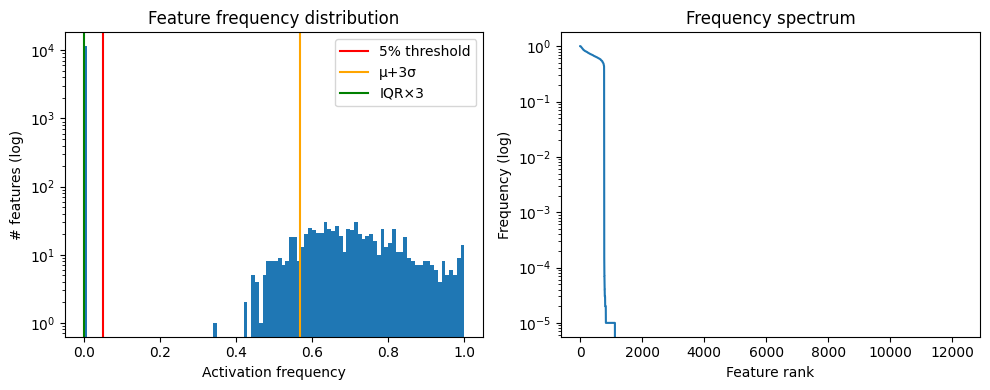

In [19]:
import torch
import numpy as np

# codes: torch.Size([100000, 12288])
# assumes values are sparse activations (0 = inactive)

# ── 1. Compute per-feature activation frequency ──────────────────────────────
is_active = (codes != 0)                          # [N, D] bool
freq = is_active.float().mean(dim=0)              # [D]  fraction of images each feature fires on

# ── 2. Summary stats ──────────────────────────────────────────────────────────
print(f"Feature frequencies — mean: {freq.mean():.4f} | median: {freq.median():.4f} "
      f"| max: {freq.max():.4f} | min: {freq.min():.4f}")

# ── 3. Detect loud features via multiple thresholds ───────────────────────────
#   (a) Fixed threshold — features active on >X% of samples
FIXED_THRESH = 0.05   # 5% is a common cutoff in SAE papers (e.g. Bricken et al.)

#   (b) Statistical outlier — mean + k*std  (catches relative outliers)
K_SIGMA = 3
stat_thresh = freq.mean() + K_SIGMA * freq.std()

#   (c) IQR-based (robust to skew)
q75, q25 = torch.quantile(freq, 0.75), torch.quantile(freq, 0.25)
iqr_thresh = q75 + 3.0 * (q75 - q25)

print(f"\nThresholds:")
print(f"  Fixed   : {FIXED_THRESH:.4f}")
print(f"  μ+3σ    : {stat_thresh:.4f}")
print(f"  IQR×3   : {iqr_thresh:.4f}")

# ── 4. Flag loud features ─────────────────────────────────────────────────────
loud_fixed = torch.where(freq > FIXED_THRESH)[0]
loud_stat  = torch.where(freq > stat_thresh)[0]
loud_iqr   = torch.where(freq > iqr_thresh)[0]

def report(name, indices, freq):
    if len(indices) == 0:
        print(f"\n[{name}]  No loud features found.")
        return
    top = indices[freq[indices].argsort(descending=True)]
    print(f"\n[{name}]  {len(indices)} loud features")
    print(f"  {'Feature':>8}  {'Freq':>8}  {'# images':>10}")
    for idx in top[:20]:   # show top 20
        f = freq[idx].item()
        print(f"  {idx.item():>8}  {f:>8.4f}  {int(f * codes.shape[0]):>10,}")

report("Fixed >5%", loud_fixed, freq)
report("μ+3σ",      loud_stat,  freq)
report("IQR×3",     loud_iqr,   freq)

# ── 5. Export all loud features sorted by frequency ──────────────────────────
# Use whichever threshold suits you; IQR is most robust
loud_idx = loud_iqr
loud_freq = freq[loud_idx]
order = loud_freq.argsort(descending=True)

loud_features = torch.stack([loud_idx[order].float(),
                              loud_freq[order]], dim=1)
# loud_features[:, 0] = feature index
# loud_features[:, 1] = activation frequency

print(f"\nFinal loud feature list (IQR threshold = {iqr_thresh:.4f}):")
print(loud_features)

# ── 6. Optional: visualise the frequency distribution ────────────────────────
try:
    import matplotlib.pyplot as plt
    f_np = freq.cpu().numpy()
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(f_np, bins=100, log=True)
    plt.axvline(FIXED_THRESH, color='r', label=f'5% threshold')
    plt.axvline(stat_thresh.item(), color='orange', label='μ+3σ')
    plt.axvline(iqr_thresh.item(), color='green', label='IQR×3')
    plt.xlabel("Activation frequency"); plt.ylabel("# features (log)")
    plt.legend(); plt.title("Feature frequency distribution")

    plt.subplot(1, 2, 2)
    plt.plot(sorted(f_np, reverse=True))
    plt.yscale('log'); plt.xlabel("Feature rank"); plt.ylabel("Frequency (log)")
    plt.title("Frequency spectrum")
    plt.tight_layout(); plt.savefig("feature_freq.png", dpi=150)
    print("\nSaved feature_freq.png")
except ImportError:
    pass

In [29]:
# freq = (codes != 0).float().mean(dim=0)

# mask = freq > 0.05
# loud_idx = mask.nonzero(as_tuple=True)[0]
# loud_freq = freq[loud_idx]

# order = loud_freq.argsort(descending=True)
# loud_idx = loud_idx[order].tolist()
# loud_freq = loud_freq[order].tolist()

# # print(f"Loud features (>5%): {len(loud_idx)} / {codes.shape[1]}\n")
# # for idx, f in zip(loud_idx, loud_freq):
# #     print(f"  feature {idx:>6}  {f:.4f}")
# loud_idx
freq = (codes != 0).float().mean(dim=0)
loud_idx = (freq > 0.1).nonzero(as_tuple=True)[0]
torch.save(loud_idx, "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/loud_features.pt")

In [ ]:
loud_idx.shape

torch.Size([771])

### before dfa

In [65]:
target_text = "Image with handwritten text in it"
# target_text = texts[540]
print(f"Searching for target text: {target_text}")
printed = 0
for feat_idx in range(feature_class_scores.shape[0]):
    if printed == 20:
        break
    scores = feature_class_scores[feat_idx].clone()
    scores[torch.isnan(scores)] = 0.0
    if scores.max() == 0:
        continue

    top_vals, top_idxs = scores.topk(15)
    top_names = [texts[int(i)] for i in top_idxs]

    for txxx in top_names:
        if target_text in txxx:
            print(f"\nFeature {feat_idx}:")
            for val, name in zip(top_vals, top_names):
                if val > 0:
                    print(f"  {name:40s}  {val:.4f}")
            printed += 1
            break

    # if target_text in top_names and top_vals[top_names.index(target_text)] > 0:
    #     print(f"\nFeature {feat_idx}:")
    #     for val, name in zip(top_vals, top_names):
    #         if val > 0:
    #             print(f"  {name:40s}  {val:.4f}")
    #     printed += 1

Searching for target text: Image with handwritten text in it

Feature 144:
  Image with handwritten text in it         1.5672
  Image with a handwritten letter           1.4359
  A pen                                     1.3269
  Image with calligraphy writing            1.2356
  short text                                1.2133
  italic words                              1.1545
  An image of a Writer                      1.1404
  italic text                               1.1087
  long text with a lot of words             1.1071
  A calligraphy                             0.9138
  Intricate calligraphy                     0.9089
  A folded paper shape                      0.8092
  An image of a Screenwriter                0.7915
  A bookmark                                0.7799
  Artwork featuring crossword grid pattern  0.7442

Feature 1256:
  Historical significance                   1.0248
  short text                                0.8359
  Evocative dialogues                      

Query top-k features: [(2520, 6.399), (2836, 3.928), (2946, 3.917), (8334, 3.663), (5997, 3.531)]


100%|██████████| 47/47 [01:58<00:00,  2.52s/it]


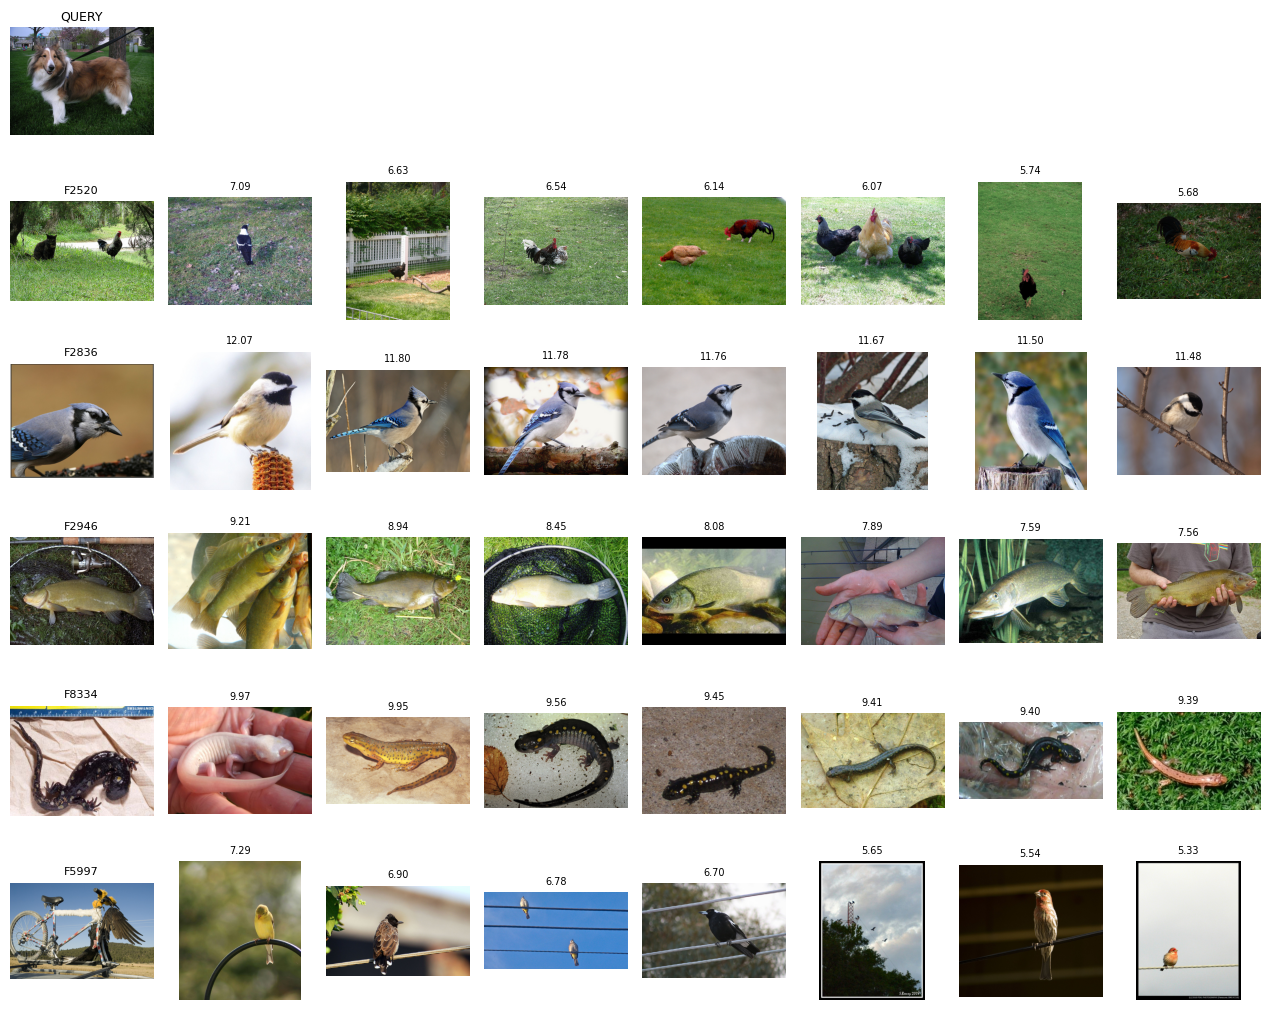

In [28]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

@torch.no_grad()
def per_image_feats(imgs, pool='max'):
    """imgs [B,3,H,W] -> [B, d_sae]. CLS-only uses CLS token; all-patches pools over tokens (max = strongest patch)."""
    _, cache = model.run_with_cache(
        imgs, names_filter=sae.cfg.hook_point,
        stop_at_layer=sae.cfg.hook_point_layer + 1,
    )
    acts   = cache[sae.cfg.hook_point]
    tokens = acts[:, 0:1, :] if sae.cfg.cls_token_only else acts
    B, T, D = tokens.shape
    _, feats = sae.encode(tokens.reshape(B * T, D))
    feats = feats.reshape(B, T, -1)
    return feats.amax(dim=1) if pool == 'max' else feats.mean(dim=1)

@torch.no_grad()
def explore(query, k=5, n_images=8, search_limit=3000, sweep_batch=64, pool='max', show=True):
    """
    query        : dataset index (int) OR a preprocessed image tensor [3,H,W]
    k            : how many of the query image's top features to inspect (1, 5, ...)
    n_images     : top dataset images to show per feature
    search_limit : how many dataset images to sweep
    """
    model.eval(); sae.eval()

    # 1) query image -> its top-k active features
    q_img = dataset[query][0] if isinstance(query, int) else query
    q_vec = per_image_feats(q_img.unsqueeze(0).to(DEVICE), pool=pool)[0]          # [d_sae]
    top_vals, top_feats = q_vec.topk(k)
    print("Query top-k features:", [(int(f), round(float(v), 3)) for f, v in zip(top_feats, top_vals)])

    # 2) sweep the dataset, record each image's activation for those k features
    n = min(search_limit, len(dataset))
    scores = torch.full((k, n), float('-inf'))
    for s in tqdm(range(0, n, sweep_batch)):
        idxs  = list(range(s, min(s + sweep_batch, n)))
        imgs  = torch.stack([dataset[j][0] for j in idxs]).to(DEVICE)
        feats = per_image_feats(imgs, pool=pool)                                 # [b, d_sae]
        scores[:, s:s + len(idxs)] = feats[:, top_feats].T.cpu()

    # 3) top images per feature
    results = {}
    for r, f in enumerate(top_feats.tolist()):
        vals, img_idxs = scores[r].topk(min(n_images, n))
        results[f] = list(zip(img_idxs.tolist(), vals.tolist()))

    # 4) display (reads raw files from disk -> no un-normalization needed)
    if show:
        rows, cols = k + 1, n_images
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.7))
        axes = axes.reshape(rows, cols)
        for c in range(cols): axes[0][c].axis('off')
        if isinstance(query, int):
            axes[0][0].imshow(Image.open(dataset.samples[query][0]).convert('RGB'))
        axes[0][0].set_title('QUERY', fontsize=9)
        for r, f in enumerate(top_feats.tolist(), start=1):
            for c in range(cols):
                ax = axes[r][c]; ax.axis('off')
                if c < len(results[f]):
                    idx, val = results[f][c]
                    ax.imshow(Image.open(dataset.samples[idx][0]).convert('RGB'))
                    ax.set_title(f"{val:.2f}", fontsize=7)
            axes[r][0].set_title(f"F{f}", fontsize=8)
        plt.tight_layout(); plt.show()

    return top_feats.tolist(), results

# usage:
coll = explore(query=23000, k=5, show=True)   # top-5 features of dataset image 0
# explore(query=0, k=1)   # single top feature

In [18]:
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
BATCH_SIZE = 50
DEVICE = 'cuda'
_, _, preprocess = open_clip.create_model_and_transforms("ViT-B-16", pretrained="laion2b_s34b_b88k")
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=preprocess) 
# dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

POOL        = 'mean'   # MUST match how feature_class_scores was built, so codes share one space
SWEEP_BATCH = 512
SAVE_PATH   = '/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/dataset_sparse_codes_all_patch.pt'

@torch.no_grad()
def per_image_feats(imgs, pool='mean'):                 # works for CLS-only or all-patches
    _, cache = model.run_with_cache(imgs, names_filter=sae.cfg.hook_point,
                                    stop_at_layer=sae.cfg.hook_point_layer + 1)
    acts   = cache[sae.cfg.hook_point]
    tokens = acts[:, 0:1, :] if sae.cfg.cls_token_only else acts
    B, T, D = tokens.shape
    _, feats = sae.encode(tokens.reshape(B * T, D))
    feats = feats.reshape(B, T, -1)
    return feats.amax(dim=1) if pool == 'max' else feats.mean(dim=1)

N, d_sae = len(dataset), sae.cfg.d_sae
print(f"{N} x {d_sae}  ->  fp16 {N*d_sae*2/1e9:.2f} GB | fp32 {N*d_sae*4/1e9:.2f} GB")

codes  = torch.zeros(N, d_sae, dtype=torch.float16)     # CPU RAM
loader = DataLoader(dataset, batch_size=SWEEP_BATCH, shuffle=False, num_workers=6)  # order-preserving
model.eval(); sae.eval()
ptr = 0
with torch.no_grad():
    for imgs, _ in tqdm(loader, total=len(loader)):
        imgs = imgs.to(DEVICE)
        b = imgs.shape[0]
        codes[ptr:ptr + b] = per_image_feats(imgs, pool=POOL).half().cpu()
        ptr += b

torch.save(codes, SAVE_PATH)
print("saved", SAVE_PATH, tuple(codes.shape))

2026-06-20 16:05:22 INFO:root: Parsing model identifier. Schema: None, Identifier: ViT-B-16
2026-06-20 16:05:22 INFO:root: Loaded built-in ViT-B-16 model config.
2026-06-20 16:05:22 DEBUG:urllib3.connectionpool: Resetting dropped connection: huggingface.co
2026-06-20 16:05:22 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_model.safetensors HTTP/1.1" 302 0
2026-06-20 16:05:22 INFO:root: Instantiating model architecture: CLIP
2026-06-20 16:05:24 INFO:root: Loading full pretrained weights from: /home/nfm/.cache/huggingface/hub/models--laion--CLIP-ViT-B-16-laion2B-s34B-b88K/snapshots/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_model.safetensors
2026-06-20 16:05:24 INFO:root: Final image preprocessing configuration set: {'size': (224, 224), 'mode': 'RGB', 'mean': (0.48145466, 0.4578275, 0.40821073), 'std': (0.26862954, 0.26130258, 0.27577711), 'interpolation': 'bicubic', 'resize_mode': 'shortest', 'fill_col

100000 x 12288  ->  fp16 2.46 GB | fp32 4.92 GB


 10%|█         | 20/196 [02:53<23:06,  7.88s/it]2026-06-20 16:08:21 DEBUG:PIL.TiffImagePlugin: tag: ImageDescription (270) - type: string (2) Tag Location: 22 - Data Location: 134 - value: <table: 33 bytes>
2026-06-20 16:08:21 DEBUG:PIL.TiffImagePlugin: tag: Make (271) - type: string (2) Tag Location: 34 - Data Location: 167 - value: b'NIKON CORPORATION\x00'
2026-06-20 16:08:21 DEBUG:PIL.TiffImagePlugin: tag: Model (272) - type: string (2) Tag Location: 46 - Data Location: 185 - value: b'NIKON D100 \x00'
2026-06-20 16:08:21 DEBUG:PIL.TiffImagePlugin: tag: XResolution (282) - type: rational (5) Tag Location: 58 - Data Location: 197 - value: b'\x00\x00\x00H\x00\x00\x00\x01'
2026-06-20 16:08:21 DEBUG:PIL.TiffImagePlugin: tag: YResolution (283) - type: rational (5) Tag Location: 70 - Data Location: 205 - value: b'\x00\x00\x00H\x00\x00\x00\x01'
2026-06-20 16:08:21 DEBUG:PIL.TiffImagePlugin: tag: ResolutionUnit (296) - type: short (3) - value: b'\x02\x00'
2026-06-20 16:08:21 DEBUG:PIL.TiffIm

saved /home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/dataset_sparse_codes_all_patch.pt (100000, 12288)


In [11]:
SAVE_PATH = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/dataset_sparse_codes_fp16.pt"
images_code = torch.load(SAVE_PATH, map_location=DEVICE)
images_code.shape

torch.Size([100000, 12288])

In [12]:
images_code.shape, feature_class_scores.shape, images_code.dtype, feature_class_scores.dtype, images_code.device, feature_class_scores.device

(torch.Size([100000, 12288]),
 torch.Size([12288, 3498]),
 torch.float16,
 torch.float32,
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [ ]:
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for letter in alphabet:
    txt = f"A photo with the letter {letter}"
    txt = "A photo of a bustling marketplace"
    if txt in texts:
        txt_ind = texts.index(txt)

        img_inds = indices_dict[str(txt_ind)]

        fig, axes = plt.subplots(1, 5, figsize=(20, 10))
        for i, ax in enumerate(axes.flatten()):
            if i < len(img_inds):
                img_path, _ = dataset.samples[img_inds[i]]
                img = plt.imread(img_path)
                ax.imshow(img)
                ax.axis('off')
            else:
                ax.axis('off')
        plt.tight_layout()

    # if letter == "H":
    #     break
    break

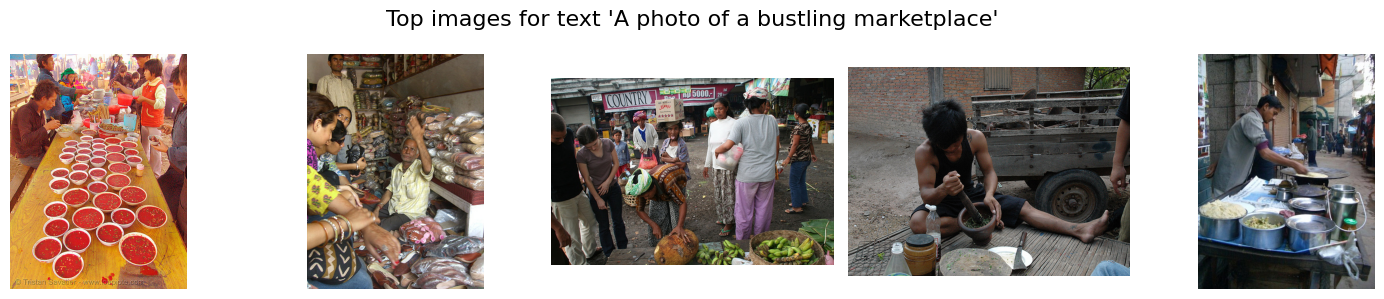

In [18]:
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for letter in alphabet:
    # txt = f"A photo with the letter {letter}"
    txt = "A photo of a bustling marketplace"
    # txt = "Image with fire"
    if txt in texts:
        txt_ind = texts.index(txt)
        txt_code = feature_class_scores[:, txt_ind].to(DEVICE, dtype=torch.float16)
        similarities = torch.matmul(images_code, txt_code)
        top_vals, top_idxs = similarities.topk(5)
        # print(f"\nTop images for text '{txt}':")
        # for val, idx in zip(top_vals, top_idxs):
        #     img_path, _ = dataset.samples[idx]
        #     print(f"  {img_path}  {val:.4f}")

        fig, axes = plt.subplots(1, 5, figsize=(15, 3))
        for ax, idx in zip(axes, top_idxs):
            img_path, _ = dataset.samples[idx]
            img = plt.imread(img_path)
            ax.imshow(img)
            ax.axis('off')
        plt.suptitle(f"Top images for text '{txt}'", fontsize=16)
        plt.tight_layout()
    
    break


In [33]:
# sae.W_enc.shape, sae.W_dec.shape, sae.W_enc.dtype, sae.W_dec.dtype, sae.W_enc.device, sae.W_dec.device

# print all parameters of sae model
# for name, param in sae.named_parameters():
#     print(f"{name}: {param.shape}, {param.dtype}, {param.device}")

sae

StandardSparseAutoencoder(
  (hook_sae_in): HookPoint()
  (hook_hidden_pre): HookPoint()
  (hook_hidden_post): HookPoint()
  (hook_sae_out): HookPoint()
  (activation_fn): TopK(
    (postact_fn): Identity()
  )
)

### dfa

In [11]:
import os
import json
import torch
from torch import einsum


TENSORS_DIR = '/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/head_acts/original_acts_all_patches'
ggg = "Original Clip"

LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

# Create a reverse lookup: "n01440764" -> 0
wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}

def residual_stack_to_logit_attn(centered_residual_stack, answer_residual_direction):
    # This subtracts the mean across the d_model dimension (dim=-1)
    # centered_residual_stack = residual_stack - residual_stack.mean(dim=-1, keepdim=True)
    
    raw_dla = torch.einsum(
        "h b d, c d -> h b c",  # h=heads, b=batch, d=d_model, c=classes
        centered_residual_stack,
        answer_residual_direction,
    )
    return raw_dla 

sae_encoder_direction = sae.W_enc.T
# sae_encoder_direction = sae.W_dec


start_inds = [45]
for xx in start_inds:

    head_idx = [28, 29]

    final_tensor = torch.zeros(1000,len(head_idx), 50, sae.cfg.d_in * sae.cfg.expansion_factor)

    pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]

    for pth in pths:
        # Extract the WNID from the filename (e.g., 'n01440764_tench.pt' -> 'n01440764')
        wnid = pth.split('_')[0]
        
        # Find its exact 0-999 integer index
        true_class_idx = wnid_to_idx[wnid]
        
        # Load and compute
        filepath = os.path.join(TENSORS_DIR, pth)
        per_head_residual = torch.load(filepath, weights_only=True).to("cuda") 
        
        per_head_attribution = residual_stack_to_logit_attn(per_head_residual[head_idx], sae_encoder_direction)
        
        # Insert it into the EXACT right row based on its official ImageNet index
        final_tensor[true_class_idx] = per_head_attribution.cpu()

    final_tensor = final_tensor.detach().cpu()

In [49]:
# import json

# pth = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/head_top_texts_attr_patch.json"

# with open(pth, "r") as f:
#     file = json.load(f)

# # sort file['Head_0']['Top_Texts'].keys() by length of the value list, descending and print the top 10
# head_key = 'Head_25'
# top_texts = file[head_key]['Top_Texts']
# sorted_top_texts = sorted(top_texts.items(), key=lambda x: len(x[1]), reverse=True)
# print(f"Top 10 texts for {file[head_key]['Head_Name']}:")
# for i in range(10):
#     text, indices = sorted_top_texts[i]
#     print(f"{i+1}. {text} - {len(indices)} images")

In [13]:
final_tensor = final_tensor.detach().cpu()

temp = torch.clone(final_tensor[:,1,:,:])
gaga = 5000
values, flat_idx = temp.reshape(-1).topk(gaga, largest=True)

# unravel flat indices to 3D coords
A, B, C = temp.shape
i = flat_idx // (B * C)
j = (flat_idx % (B * C)) // C
k = flat_idx % C
indices = torch.stack([i, j, k], dim=1)


top_names = []
avg_vals = {}
for i in range(gaga):
    top_names.append(indices[i][2].item())
    avg_vals[indices[i][2].item()] = avg_vals.get(indices[i][2].item(), []) + [values[i].item()]

feat_inds = []
from collections import Counter
name_counts = Counter(top_names)
for name, count in name_counts.most_common(20):
    print(f"{name}: {count} : {sum(avg_vals[name])/len(avg_vals[name]):.3f}", end="||")
    feat_inds.append((name, count))
print("\n" + "-"*50)

for idx, count in feat_inds:
    feat_vec = feature_class_scores[idx]
    top_vals, top_idxs = feat_vec.topk(5)
    print(f"\nFeature {idx}: {count}")
    for val, i in zip(top_vals, top_idxs):
        if val > 0:
            print(f"  {texts[i]:40s}  {val:.4f}")

3255: 1973 : 0.368||3757: 1211 : 0.400||6179: 373 : 0.427||10290: 350 : 0.378||5972: 243 : 0.462||4829: 121 : 0.375||1432: 78 : 0.402||807: 51 : 0.400||9318: 47 : 0.381||1641: 46 : 0.399||1850: 34 : 0.406||610: 34 : 0.397||4787: 32 : 0.370||8389: 28 : 0.389||8593: 22 : 0.388||4690: 19 : 0.404||5289: 18 : 0.387||7345: 18 : 0.366||10092: 17 : 0.376||274: 15 : 0.364||
--------------------------------------------------

Feature 3255: 1973
  Artwork featuring crossword-like motifs   2.2089
  Artwork featuring crossword grid pattern  2.0557
  Image with a labyrinth or maze            1.4485
  A maze                                    1.2682
  Image with a maze-like structure          1.2644

Feature 3757: 1211
  ornate cathedral                          2.3180
  Artwork featuring crossword grid pattern  2.2651
  Grand cathedral interior                  2.2386
  Majestic architecture                     2.2360
  Artwork featuring crossword-like motifs   2.1895

Feature 6179: 373
  A barbed w

In [ ]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
pth = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/corrected_fcs_topk_cls.pt"
feature_class_scores = torch.load(pth, map_location=DEVICE)

pth2 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/demos/activation_cache/dataset_sparse_codes_fp16.pt"
codes = torch.load(pth2, map_location=DEVICE)

feature_class_scores.shape, codes.shape

(torch.Size([12288, 3498]), torch.Size([100000, 12288]))

In [7]:
texts_path = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(texts_path, "r", encoding="utf-8") as f:
    texts = [line.strip() for line in f if line.strip()]

In [26]:
import matplotlib.pyplot as plt
from collections import Counter


IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
BATCH_SIZE = 50
DEVICE = 'cuda'
# _, _, preprocess = open_clip.create_model_and_transforms("ViT-B-16", pretrained="laion2b_s34b_b88k")
dataset = ImageFolder(IMAGENET_VAL_DIR)

In [34]:
import matplotlib.pyplot as plt

TEXTWIDTH_PT = 345.0                  # <-- your \the\textwidth value
TEXTWIDTH_IN = TEXTWIDTH_PT / 72.27   # TeX points -> inches

def setup(c, aspect=0.65, base=12):
    """
    c      : the scale you'll use in \includegraphics[width=c\textwidth]
    aspect : height / width of the figure
    base   : point size the body text should appear as in the PDF
    """
    w = c * TEXTWIDTH_IN
    plt.rcParams.update({
        'figure.figsize'  : (w, w * aspect),
        'font.family'     : 'serif',
        'font.size'       : base,        # comes out as `base` pt, scale = 1
        'axes.titlesize'  : base,
        'axes.labelsize'  : base,
        'xtick.labelsize' : base - 2,
        'ytick.labelsize' : base - 2,
        'legend.fontsize' : base - 2,
        'figure.constrained_layout.use': True,  # keeps labels inside fig size
    })

<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_2707403/752934072.py:7: SyntaxWarning: invalid escape sequence '\i'
  """


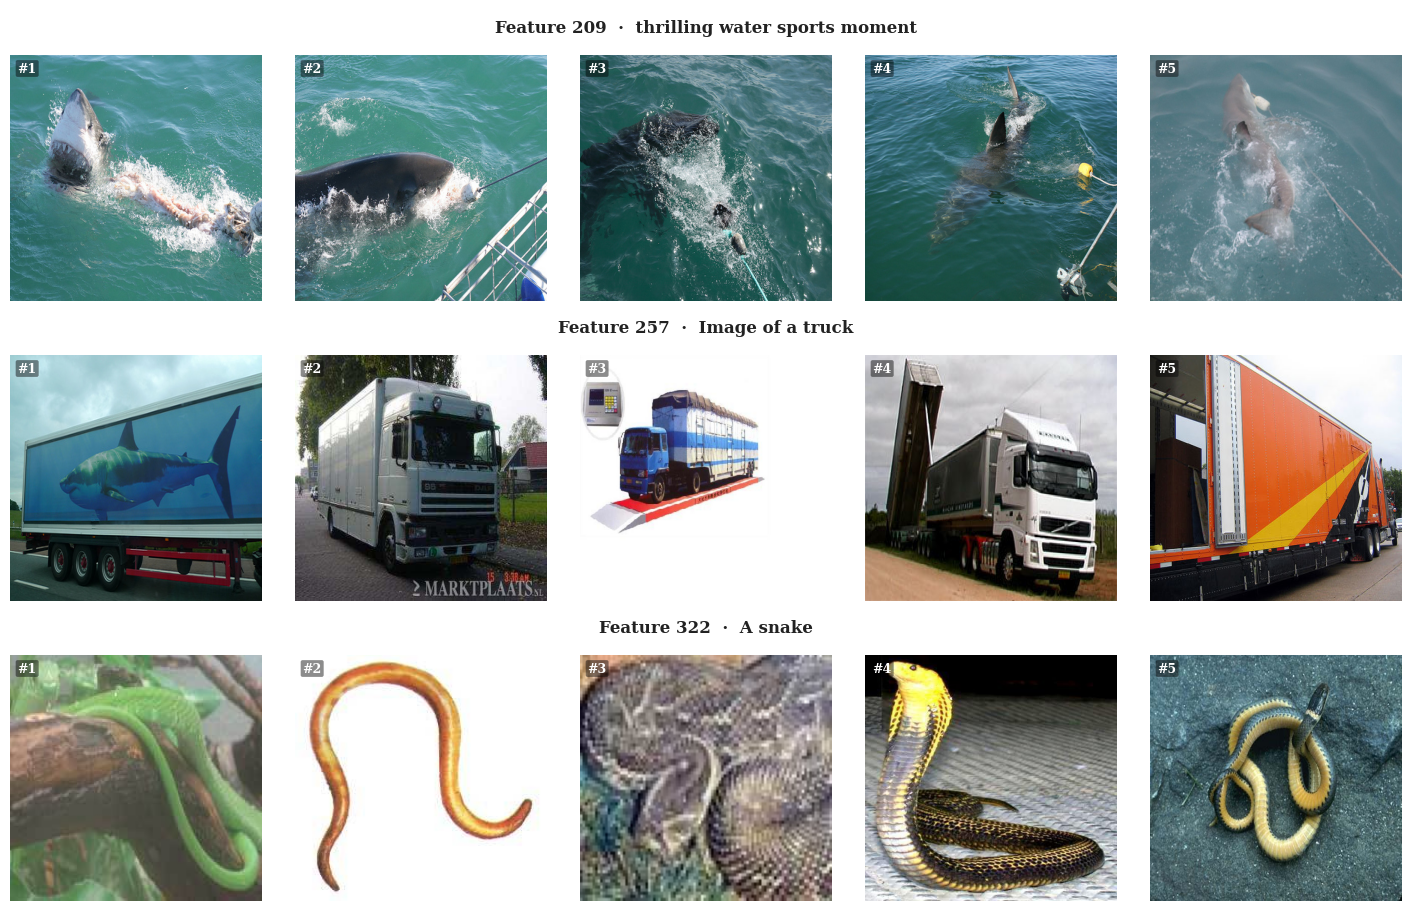

In [38]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

skip_list = [207, 294]

selected_feats = []
for i in range(100, feature_class_scores.shape[0]):
    if i in skip_list:
        continue
    scores = feature_class_scores[i].clone()
    scores[torch.isnan(scores)] = 0.0
    if scores.max() >= 0.9:
        selected_feats.append(i)
    if len(selected_feats) == 3:
        break

n_feats = len(selected_feats)
n_imgs = 5

# Two rows per feature: a slim header row + a tall image row
height_ratios = []
for _ in selected_feats:
    height_ratios.extend([0.15, 1.0])

setup(c=0.5)
fig = plt.figure(figsize=(14, 3.0 * n_feats))
gs = gridspec.GridSpec(
    n_feats * 2, n_imgs,
    figure=fig,
    height_ratios=height_ratios,
    hspace=0.04,   # vertical gap between rows (very tight)
    wspace=0.02,   # horizontal gap between images (nearly zero)
)

for row, feat_idx in enumerate(selected_feats):
    scores = feature_class_scores[feat_idx].clone()
    scores[torch.isnan(scores)] = 0.0
    top_val, top_idx = scores.topk(1)
    top_label = texts[top_idx[0]]
    top_score = top_val[0].item()

    # ── header row: spans all 5 image columns ──────────────────────────────
    text_ax = fig.add_subplot(gs[row * 2, :])
    text_ax.axis("off")
    text_ax.set_facecolor("#f5f5f5")
    text_ax.text(
        0.5, 0.5,
        f"Feature {feat_idx}  ·  {top_label}",
        fontsize=12,
        fontweight="bold",
        ha="center",
        va="center",
        transform=text_ax.transAxes,
        color="#222222",
    )

    # ── image row ──────────────────────────────────────────────────────────
    top_img_idxs = torch.topk(codes[:, feat_idx], k=n_imgs).indices
    for col, img_idx in enumerate(top_img_idxs):
        img_path, _ = dataset.samples[img_idx]
        img = Image.open(img_path).convert("RGB")
        ax = fig.add_subplot(gs[row * 2 + 1, col])
        ax.imshow(img, aspect="auto")
        ax.axis("off")
        # rank label in the corner of each image
        ax.text(
            0.03, 0.97, f"#{col + 1}",
            transform=ax.transAxes,
            fontsize=9, color="white", fontweight="bold",
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.45, lw=0),
        )

# plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots3/sae_features.png", dpi=150, bbox_inches="tight")
plt.show()